# Chapter 257 — Markov Chains
### Part VIII: Probability

A Markov chain is a stochastic process where the future depends only on the present — not the past. This memoryless property, called the **Markov property**, makes these chains tractable while still capturing rich real-world dynamics: web page ranking, text generation, queueing systems, and the backbone of MCMC sampling.

**Prerequisites:** Probability Rules (ch244), Conditional Probability (ch245), Random Variables (ch247), Matrix Multiplication (ch153 — Part VI), Expected Value (ch249).

## 1. The Markov Property

A sequence of random variables $X_0, X_1, X_2, \ldots$ is a Markov chain if:

$$P(X_{n+1} = j \mid X_n = i, X_{n-1} = i_{n-1}, \ldots, X_0 = i_0) = P(X_{n+1} = j \mid X_n = i)$$

The conditional probabilities $P_{ij} = P(X_{n+1} = j \mid X_n = i)$ form the **transition matrix** $P$, where:
- $P_{ij} \geq 0$ for all $i, j$
- $\sum_j P_{ij} = 1$ for each row $i$ (rows are probability distributions)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import linalg

rng = np.random.default_rng(42)

# Weather model: states = {Sunny, Cloudy, Rainy}
states = ['Sunny', 'Cloudy', 'Rainy']
n_states = len(states)

# Transition matrix P[i,j] = P(tomorrow=j | today=i)
P = np.array([
    [0.7, 0.2, 0.1],   # Sunny -> Sunny/Cloudy/Rainy
    [0.3, 0.4, 0.3],   # Cloudy -> ...
    [0.2, 0.4, 0.4],   # Rainy -> ...
])

# Verify it's a valid transition matrix
assert np.allclose(P.sum(axis=1), 1.0), "Rows must sum to 1"
assert (P >= 0).all(), "All probabilities must be non-negative"

print("Transition matrix P:")
print(f"{'':>8}", end="")
for s in states:
    print(f"{s:>10}", end="")
print()
for i, row_state in enumerate(states):
    print(f"{row_state:>8}", end="")
    for val in P[i]:
        print(f"{val:>10.2f}", end="")
    print()

Transition matrix P:
             Sunny    Cloudy     Rainy
   Sunny      0.70      0.20      0.10
  Cloudy      0.30      0.40      0.30
   Rainy      0.20      0.40      0.40


## 2. Simulating a Markov Chain

Empirical state frequencies over 365 days:
  Sunny: 0.503
  Cloudy: 0.270
  Rainy: 0.227


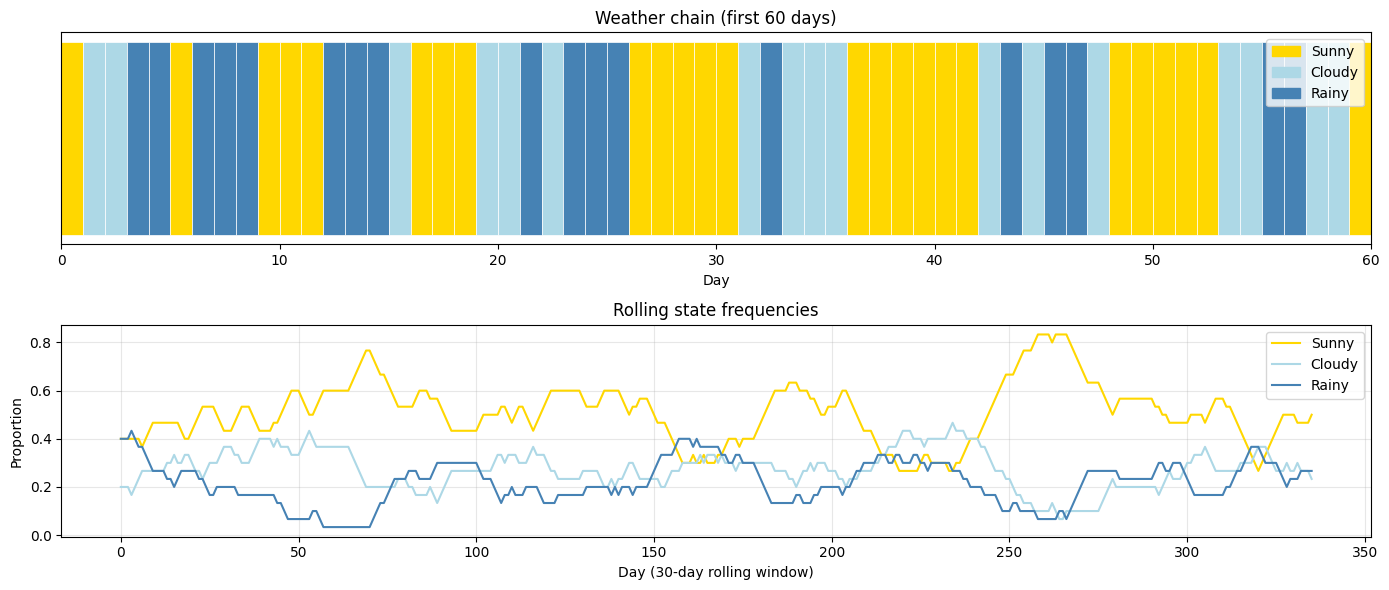

In [2]:
def simulate_markov_chain(P, start_state, n_steps, rng):
    """Simulate a discrete-time Markov chain.
    
    Args:
        P: transition matrix (n_states x n_states)
        start_state: integer index of starting state
        n_steps: number of transitions to simulate
        rng: numpy random generator
    
    Returns:
        array of visited state indices (length n_steps + 1)
    """
    n_states = P.shape[0]
    chain = np.zeros(n_steps + 1, dtype=int)
    chain[0] = start_state
    
    for t in range(n_steps):
        current = chain[t]
        # Sample next state from row current of P
        chain[t + 1] = rng.choice(n_states, p=P[current])
    
    return chain

# Simulate 365 days of weather starting from Sunny
n_days = 365
chain = simulate_markov_chain(P, start_state=0, n_steps=n_days, rng=rng)

# Empirical frequency of each state
from collections import Counter
counts = Counter(chain)
print("Empirical state frequencies over 365 days:")
for i, state in enumerate(states):
    print(f"  {state}: {counts[i]/len(chain):.3f}")

# Plot the chain
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

colors = ['gold', 'lightblue', 'steelblue']
for day in range(min(60, n_days)):
    axes[0].barh(0, 1, left=day, color=colors[chain[day]], height=0.8, edgecolor='white', linewidth=0.5)
axes[0].set_xlim(0, 60)
axes[0].set_yticks([])
axes[0].set_xlabel('Day')
axes[0].set_title('Weather chain (first 60 days)')
patches = [mpatches.Patch(color=colors[i], label=states[i]) for i in range(3)]
axes[0].legend(handles=patches, loc='upper right')

# State proportions over time
window = 30
proportions = np.zeros((n_days + 1 - window, 3))
for t in range(n_days + 1 - window):
    for s in range(3):
        proportions[t, s] = np.mean(chain[t:t+window] == s)

for s in range(3):
    axes[1].plot(proportions[:, s], color=colors[s], label=states[s])
axes[1].set_xlabel('Day (30-day rolling window)')
axes[1].set_ylabel('Proportion')
axes[1].set_title('Rolling state frequencies')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('markov_chain_simulation.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. The n-Step Distribution and Convergence

If $\pi_0$ is the initial distribution (row vector), then after $n$ steps:

$$\pi_n = \pi_0 \cdot P^n$$

This uses matrix powers *(introduced in ch153 — Matrix Multiplication)*. As $n \to \infty$, for an **ergodic** chain (irreducible + aperiodic), $\pi_n$ converges to a unique **stationary distribution** $\pi^*$ satisfying:

$$\pi^* = \pi^* P \quad \text{and} \quad \sum_i \pi^*_i = 1$$

Stationary distribution π*:
  P(Sunny) = 0.4615
  P(Cloudy) = 0.3077
  P(Rainy) = 0.2308

Verification π*P ≈ π*: True


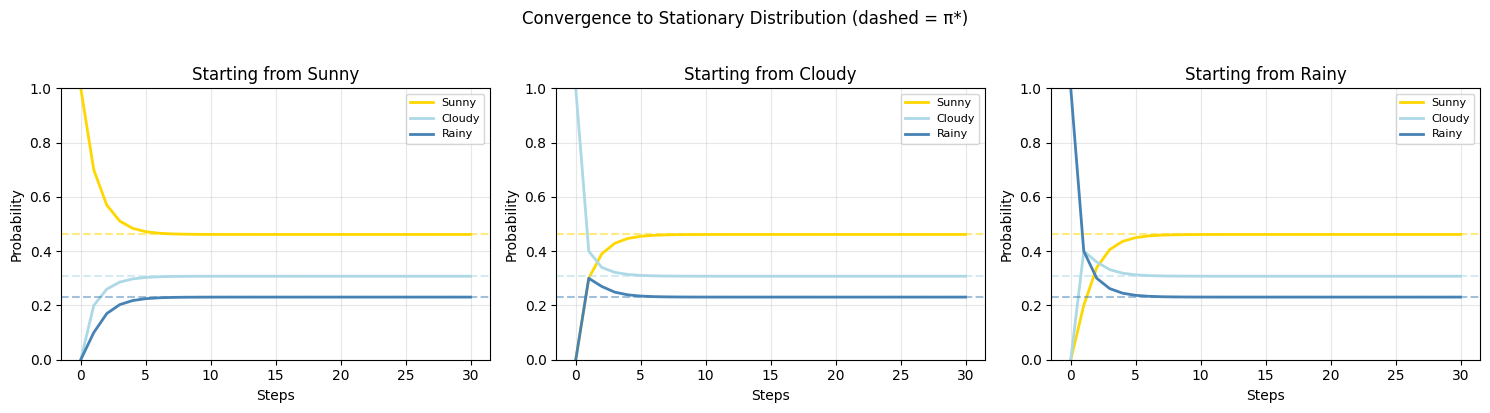

In [3]:
# Compute stationary distribution analytically
# Solve: pi P = pi  <=>  pi (P - I)^T = 0  + normalization

def stationary_distribution(P):
    """Find stationary distribution of a transition matrix.
    Solves pi P = pi with pi summing to 1.
    """
    n = P.shape[0]
    # Build (P^T - I) augmented with normalization row
    A = (P.T - np.eye(n))
    # Replace last row with normalization constraint sum(pi) = 1
    A[-1, :] = 1.0
    b = np.zeros(n)
    b[-1] = 1.0
    pi = linalg.solve(A, b)
    return pi

pi_star = stationary_distribution(P)
print("Stationary distribution π*:")
for i, state in enumerate(states):
    print(f"  P({state}) = {pi_star[i]:.4f}")
print(f"\nVerification π*P ≈ π*: {np.allclose(pi_star @ P, pi_star)}")

# Show convergence from different starting states
n_steps = 30
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for start in range(3):
    pi_0 = np.zeros(3)
    pi_0[start] = 1.0  # start deterministically in state `start`
    
    distributions = [pi_0.copy()]
    Pn = np.eye(3)
    for _ in range(n_steps):
        Pn = Pn @ P
        distributions.append(pi_0 @ Pn)
    
    distributions = np.array(distributions)
    colors_plot = ['gold', 'lightblue', 'steelblue']
    
    for s in range(3):
        axes[start].plot(distributions[:, s], color=colors_plot[s],
                         label=states[s], linewidth=2)
        axes[start].axhline(pi_star[s], color=colors_plot[s],
                            linestyle='--', alpha=0.5)
    
    axes[start].set_title(f'Starting from {states[start]}')
    axes[start].set_xlabel('Steps')
    axes[start].set_ylabel('Probability')
    axes[start].legend(fontsize=8)
    axes[start].grid(True, alpha=0.3)
    axes[start].set_ylim(0, 1)

plt.suptitle('Convergence to Stationary Distribution (dashed = π*)', y=1.02)
plt.tight_layout()
plt.savefig('markov_convergence.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Eigenvalue Connection

The stationary distribution is the **left eigenvector** of $P$ corresponding to eigenvalue 1 *(eigenvalues introduced in ch169 — Part VI)*. All other eigenvalues $|\lambda_i| < 1$ for an ergodic chain, and the **mixing time** is governed by $|\lambda_2|$ (the second-largest eigenvalue by magnitude): smaller $|\lambda_2|$ means faster mixing.

In [4]:
# Eigenvalue analysis of transition matrix
eigenvalues, left_eigvecs = linalg.eig(P.T)  # left eigenvectors of P

# Sort by magnitude descending
idx = np.argsort(np.abs(eigenvalues))[::-1]
eigenvalues = eigenvalues[idx]
left_eigvecs = left_eigvecs[:, idx]

print("Eigenvalues of P (sorted by |λ|):")
for i, ev in enumerate(eigenvalues):
    print(f"  λ_{i+1} = {ev.real:.6f}")

# The dominant eigenvector (λ=1) gives the stationary distribution
dominant = left_eigvecs[:, 0].real
dominant = dominant / dominant.sum()  # normalize to sum to 1
print(f"\nDominant eigenvector (normalized) = stationary distribution:")
for i, state in enumerate(states):
    print(f"  {state}: {dominant[i]:.4f}  (vs analytical: {pi_star[i]:.4f})")

lambda2 = abs(eigenvalues[1].real)
# Mixing time ≈ 1 / log(1/|λ_2|)
mixing_time = 1 / np.log(1 / lambda2)
print(f"\n|λ_2| = {lambda2:.4f}")
print(f"Approximate mixing time: {mixing_time:.1f} steps")

Eigenvalues of P (sorted by |λ|):
  λ_1 = 1.000000
  λ_2 = 0.456155
  λ_3 = 0.043845

Dominant eigenvector (normalized) = stationary distribution:
  Sunny: 0.4615  (vs analytical: 0.4615)
  Cloudy: 0.3077  (vs analytical: 0.3077)
  Rainy: 0.2308  (vs analytical: 0.2308)

|λ_2| = 0.4562
Approximate mixing time: 1.3 steps


## 5. PageRank as a Markov Chain

Google's original PageRank algorithm models web surfing as a Markov chain. A random surfer follows links randomly, with a small probability of teleporting to any page (the damping factor). The stationary distribution gives page importance.

Converged in 56 iterations

PageRank scores:
  #1: Page 4 — 0.2495
  #2: Page 0 — 0.2172
  #3: Page 1 — 0.1925
  #4: Page 5 — 0.1678
  #5: Page 2 — 0.0865
  #6: Page 3 — 0.0865


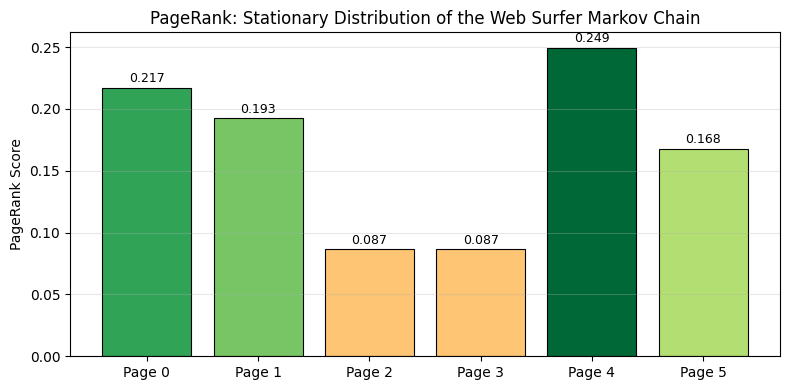

In [5]:
def pagerank(adjacency_matrix, damping=0.85, max_iter=100, tol=1e-8):
    """Compute PageRank via power iteration.
    
    Args:
        adjacency_matrix: (n x n) where A[i,j]=1 means page i links to page j
        damping: probability of following a link (vs teleporting)
        max_iter: maximum power iterations
        tol: convergence tolerance
    
    Returns:
        PageRank vector (stationary distribution of the Markov chain)
    """
    n = adjacency_matrix.shape[0]
    
    # Row-normalize adjacency to get transition probabilities
    out_degree = adjacency_matrix.sum(axis=1, keepdims=True)
    # Handle dangling nodes (no outlinks) — teleport everywhere
    dangling = (out_degree == 0)
    out_degree_safe = np.where(dangling, 1, out_degree)
    T = adjacency_matrix / out_degree_safe  # row-stochastic
    T[dangling.flatten()] = 1.0 / n  # dangling nodes teleport
    
    # Google matrix: damped random walk + uniform teleportation
    G = damping * T + (1 - damping) / n * np.ones((n, n))
    
    # Power iteration: start from uniform distribution
    pi = np.ones(n) / n
    for iteration in range(max_iter):
        pi_new = pi @ G
        if np.linalg.norm(pi_new - pi, 1) < tol:
            print(f"Converged in {iteration+1} iterations")
            break
        pi = pi_new
    return pi_new

# Small web graph: 6 pages
# Page 0 (Hub): links to 1, 2, 3
# Page 1: links to 0, 4
# Page 2: links to 0
# Page 3: links to 0, 5
# Page 4: links to 1, 5 (authority)
# Page 5: links to 4 (authority)
A = np.array([
    [0, 1, 1, 1, 0, 0],
    [1, 0, 0, 0, 1, 0],
    [1, 0, 0, 0, 0, 0],
    [1, 0, 0, 0, 0, 1],
    [0, 1, 0, 0, 0, 1],
    [0, 0, 0, 0, 1, 0],
], dtype=float)

pr = pagerank(A)
page_names = [f'Page {i}' for i in range(6)]
print("\nPageRank scores:")
ranked = sorted(enumerate(pr), key=lambda x: -x[1])
for rank, (i, score) in enumerate(ranked, 1):
    print(f"  #{rank}: {page_names[i]} — {score:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
colors_pr = plt.cm.RdYlGn(pr / pr.max())
bars = ax.bar(page_names, pr, color=colors_pr, edgecolor='black', linewidth=0.8)
ax.set_ylabel('PageRank Score')
ax.set_title('PageRank: Stationary Distribution of the Web Surfer Markov Chain')
for bar, score in zip(bars, pr):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{score:.3f}', ha='center', va='bottom', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('pagerank_markov.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Summary

| Concept | Definition | Role |
|---------|-----------|------|
| Transition matrix $P$ | $P_{ij} = P(X_{n+1}=j|X_n=i)$ | Encodes all chain dynamics |
| Stationary dist $\pi^*$ | $\pi^* P = \pi^*$ | Long-run frequency of states |
| Ergodic chain | Irreducible + aperiodic | Guarantees unique $\pi^*$ and convergence |
| Mixing time | $\sim 1/\log(1/|\lambda_2|)$ | Speed of convergence to $\pi^*$ |
| PageRank | Stationary dist of damped web surfer | Practical Markov chain application |

## 9. Forward References

- **ch258 — Random Walks**: A random walk is a Markov chain on the integers — the simplest non-trivial chain, with deep connections to Brownian motion and diffusion.
- **ch290 — Clustering** *(Part IX)*: Spectral clustering uses eigenvectors of a graph's random-walk matrix — the same eigenvalue structure analyzed here determines cluster membership.
- **ch283 — Bayesian Statistics** *(Part IX)*: MCMC (Markov Chain Monte Carlo) constructs a Markov chain whose stationary distribution is the target posterior — the most powerful general Bayesian inference tool.